# 02 — Visualizações

Galeria de gráficos reutilizada no dashboard (versões interativas em plotly lá).
Convenções: renda é **ordinal** (rampa azul clara→escura), regiões usam cores categóricas
fixas com rótulo direto, magnitude usa azul sequencial.

In [1]:
import sys, json, warnings
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from config import settings
from src.utils.io import load_parquet
from src.analysis import eda
from src.viz import style

style.use_matplotlib()
pd.set_option("display.max_columns", 40, "display.width", 160, "display.precision", 2)
abt = load_parquet("gold", "abt_country_year")
print(f"ABT: {abt.shape[0]:,} linhas x {abt.shape[1]} colunas | "
      f"{abt.country_id.nunique()} paises | {abt.year.min()}-{abt.year.max()}")

ABT: 7,378 linhas x 37 colunas | 217 paises | 1990-2023


## 1. Mapa: expectativa de vida mais recente por país

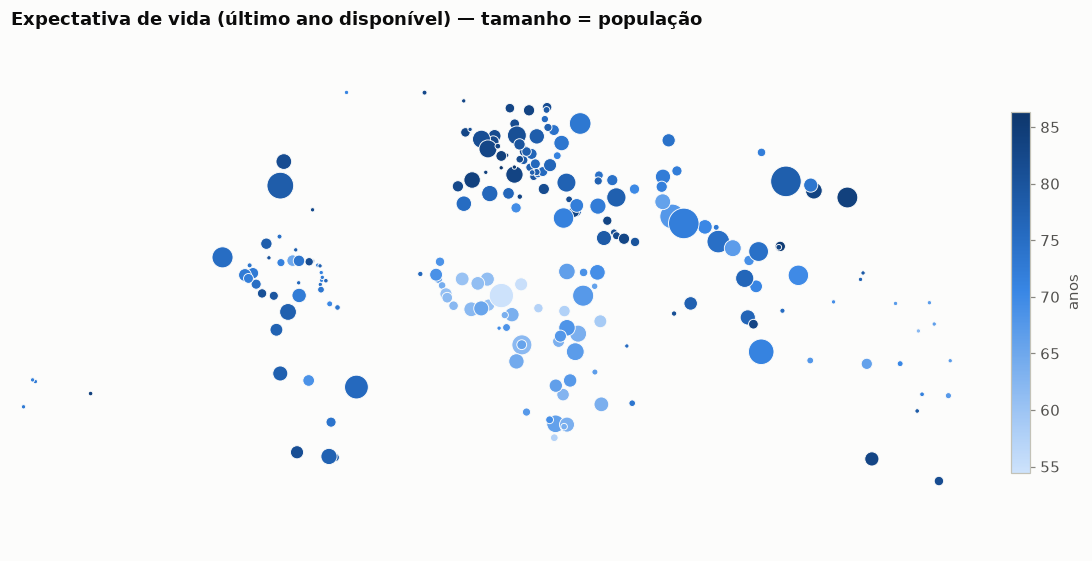

In [2]:
snap = eda.latest_snapshot(abt, "life_expectancy").merge(
    load_parquet("silver", "countries_dim")[["country_id", "latitude", "longitude"]], on="country_id")
snap = snap.merge(abt[abt.year == 2023][["country_id", "population"]], on="country_id", how="left")
fig, ax = plt.subplots(figsize=(11, 5.2))
sc = ax.scatter(snap.longitude, snap.latitude, c=snap.life_expectancy, cmap=style.mpl_sequential(),
                s=np.clip(np.sqrt(snap.population.fillna(1e5)) / 60, 8, 400),
                edgecolor=style.INK["surface"], linewidth=0.6)
ax.set_xlim(-180, 180); ax.set_ylim(-60, 80); ax.grid(False)
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values(): s.set_visible(False)
fig.colorbar(sc, ax=ax, shrink=0.7, label="anos")
ax.set_title("Expectativa de vida (último ano disponível) — tamanho = população")
plt.tight_layout(); plt.show()

O dashboard traz o coroplético interativo (plotly, por ISO3) com seletor de indicador e ano.

## 2. Evolução por região (mediana)

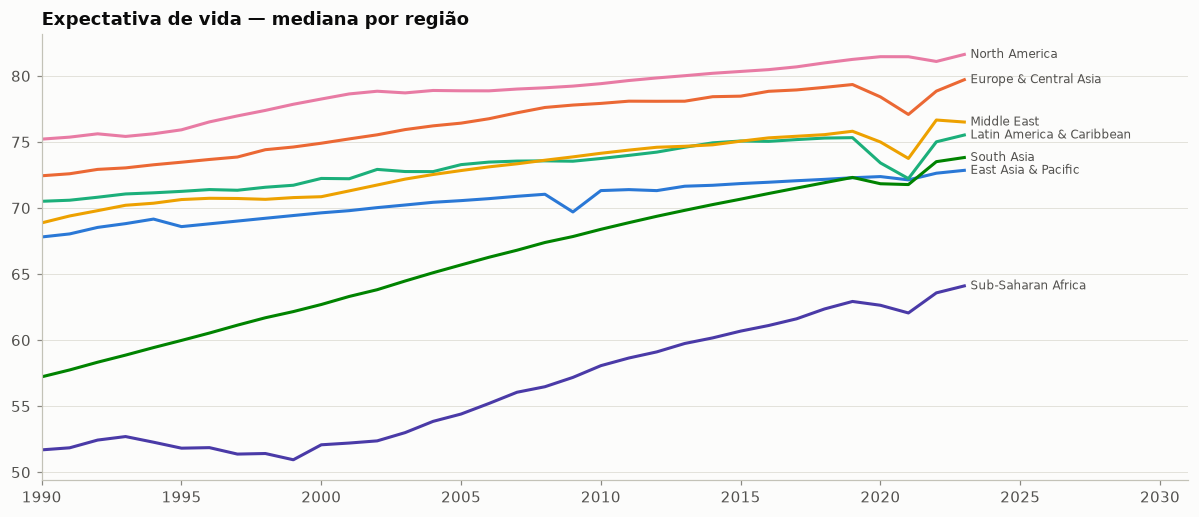

In [3]:
fig, ax = plt.subplots(figsize=(11, 4.8))
med = abt.groupby(["region", "year"]).life_expectancy.median().reset_index()
for reg in style.REGION_ORDER:
    s = med[med.region == reg]
    ax.plot(s.year, s.life_expectancy, color=style.REGION_COLORS[reg])
    ax.annotate(reg.split(",")[0], (s.year.iloc[-1], s.life_expectancy.iloc[-1]), xytext=(4, 0),
                textcoords="offset points", fontsize=8, color=style.INK["secondary"], va="center")
ax.set_xlim(1990, 2031); ax.set_title("Expectativa de vida — mediana por região")
plt.tight_layout(); plt.show()

## 3. Boxplots por grupo de renda (2019)

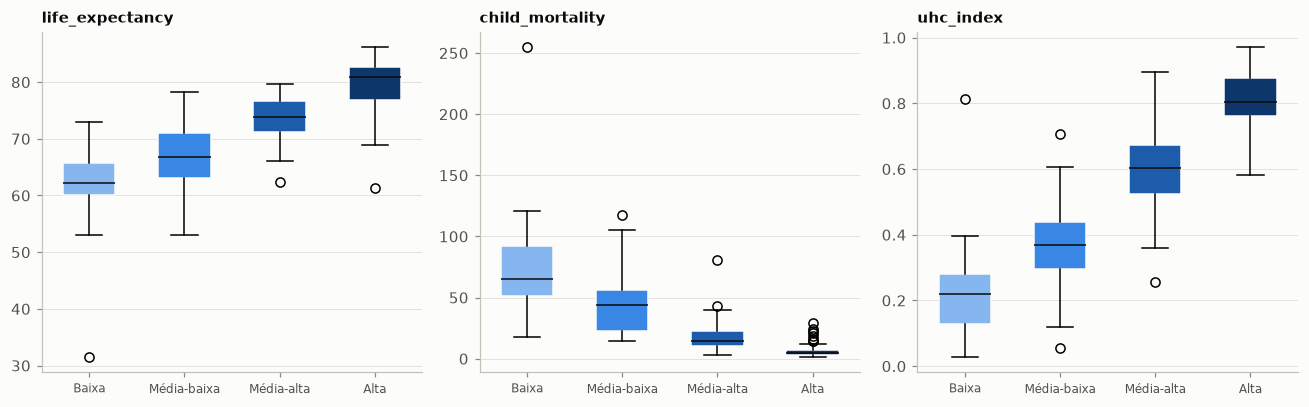

In [4]:
s19 = abt[abt.year == 2019]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
for ax, c in zip(axes, ["life_expectancy", "child_mortality", "uhc_index"]):
    data = [s19.loc[s19.income == g, c].dropna() for g in style.INCOME_ORDER]
    bp = ax.boxplot(data, patch_artist=True, widths=0.55, medianprops=dict(color=style.INK["primary"]))
    for patch, g in zip(bp["boxes"], style.INCOME_ORDER):
        patch.set_facecolor(style.INCOME_COLORS[g]); patch.set_edgecolor(style.INK["surface"])
    ax.set_xticks(range(1, 5), ["Baixa", "Média-baixa", "Média-alta", "Alta"], fontsize=8)
    ax.set_title(c, fontsize=10)
plt.tight_layout(); plt.show()

## 4. Preston curve: PIB per capita × expectativa de vida

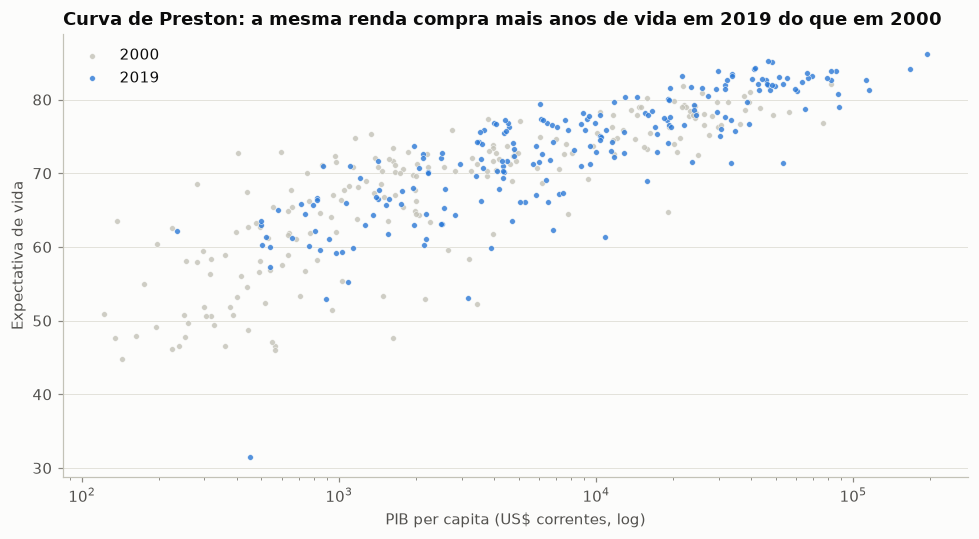

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for yr, color in [(2000, style.CONTEXT), (2019, style.HIGHLIGHT)]:
    d = abt[abt.year == yr].dropna(subset=["gdp_per_capita", "life_expectancy"])
    ax.scatter(d.gdp_per_capita, d.life_expectancy, s=14, color=color, alpha=0.8, label=str(yr),
               edgecolor=style.INK["surface"], linewidth=0.4)
ax.set_xscale("log"); ax.legend()
ax.set_xlabel("PIB per capita (US$ correntes, log)"); ax.set_ylabel("Expectativa de vida")
ax.set_title("Curva de Preston: a mesma renda compra mais anos de vida em 2019 do que em 2000")
plt.tight_layout(); plt.show()

**Leitura:** a relação é côncava no log do PIB (ganhos grandes na base da distribuição) e a
**curva se desloca para cima** entre 2000 e 2019: a mesma renda compra mais anos de vida
(tecnologia, vacinas, antirretrovirais). É o motivo de os testes terem efeitos fixos de ano.

## 5. Proxy UHC vs SCI oficial

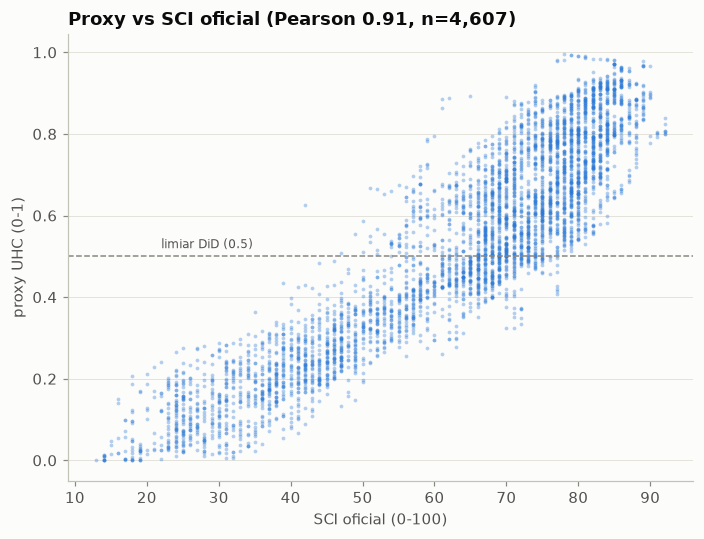

In [6]:
d = abt.dropna(subset=["uhc_index", "uhc_sci"])
fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(d.uhc_sci, d.uhc_index, s=6, alpha=0.35, color=style.HIGHLIGHT, lw=0)
ax.axhline(0.5, color=style.INK["muted"], lw=1, ls="--")
ax.annotate("limiar DiD (0.5)", (22, 0.52), fontsize=8, color=style.INK["secondary"])
ax.set_xlabel("SCI oficial (0-100)"); ax.set_ylabel("proxy UHC (0-1)")
ax.set_title(f"Proxy vs SCI oficial (Pearson {d.uhc_index.corr(d.uhc_sci):.2f}, n={len(d):,})")
plt.tight_layout(); plt.show()

## 6. Heatmap: expectativa de vida por região × ano

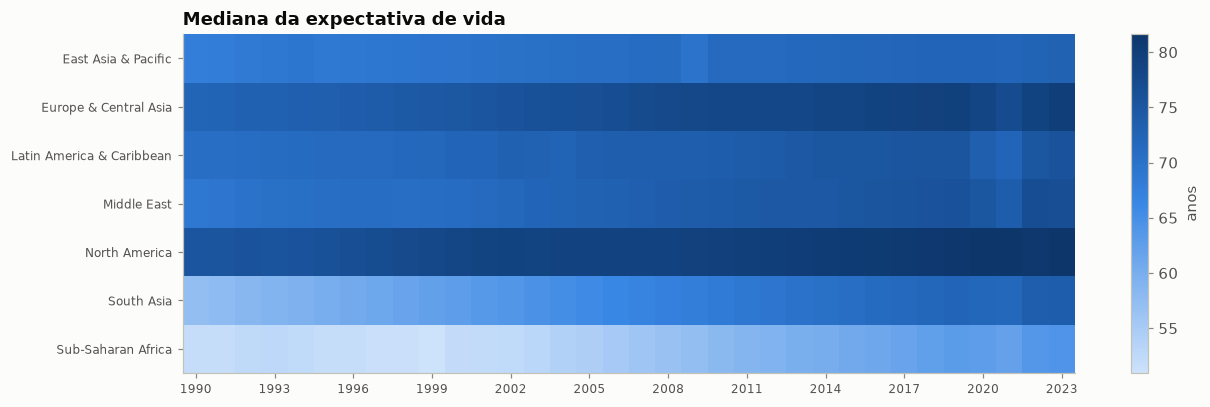

In [7]:
piv = abt.groupby(["region", "year"]).life_expectancy.median().unstack()
fig, ax = plt.subplots(figsize=(12, 3.8))
im = ax.imshow(piv.values, aspect="auto", cmap=style.mpl_sequential())
ax.set_yticks(range(len(piv.index)), [r.split(",")[0] for r in piv.index], fontsize=8)
xt = list(range(0, len(piv.columns), 3)); ax.set_xticks(xt, [piv.columns[i] for i in xt], fontsize=8)
ax.grid(False); fig.colorbar(im, ax=ax, label="anos"); ax.set_title("Mediana da expectativa de vida")
plt.tight_layout(); plt.show()